# 🧮 Math Refresher — Linear Algebra, Probability & Calculus for ML

This is the last Foundation topic, and the one every Classical ML algorithm ahead ultimately reduces to. Linear/Logistic Regression is linear algebra + calculus. Naive Bayes is probability theory. Gradient Boosting is calculus (gradients) applied repeatedly. This notebook builds working intuition for all three pillars, with code demonstrations tied directly to what's coming next.

📖 Full mathematical explanation and formulas: [README.md](README.md)


## 1. Linear Algebra — Vectors & Norms

A **norm** measures a vector's "size." The two you'll see constantly:

- **L2 norm** (Euclidean length) — used in Ridge regression's penalty, KNN's distance metric, standard deviation
- **L1 norm** (Manhattan/taxicab length) — used in Lasso regression's penalty, robust to outliers

Formulas and geometric intuition are in the README; here we compute both directly.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [2]:
sns.set_theme(style="whitegrid")
np.random.seed(42)
v = np.array([3, 4])


In [3]:
l2_norm = np.linalg.norm(v, ord=2)   # sqrt(3^2 + 4^2) = 5, the classic 3-4-5 triangle
l1_norm = np.linalg.norm(v, ord=1)   # |3| + |4| = 7


In [4]:
print(f"Vector: {v}")
print(f"L2 norm (Euclidean length): {l2_norm}")
print(f"L1 norm (Manhattan length): {l1_norm}")


Vector: [3 4]
L2 norm (Euclidean length): 5.0
L1 norm (Manhattan length): 7.0


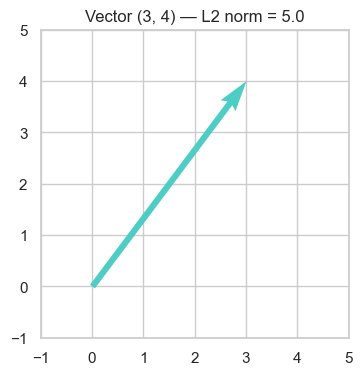

In [5]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.quiver(0, 0, v[0], v[1], angles="xy", scale_units="xy", scale=1, color="#4ecdc4", width=0.02)
ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
ax.set_title(f"Vector (3, 4) — L2 norm = {l2_norm:.1f}")
ax.set_aspect("equal")
plt.show()


## 2. Linear Algebra — Matrix Inverse & Solving Linear Systems

Solving $A\mathbf{x} = \mathbf{b}$ for $\mathbf{x}$ is the core computation behind the **Normal Equation**, the closed-form solution to Linear Regression covered in the very next repo. We solve it two ways — via explicit matrix inversion, and via NumPy's more numerically stable solver — and confirm they agree.


In [6]:
A = np.array([[2, 1], [1, 3]], dtype=float)
b = np.array([8, 13], dtype=float)


In [7]:
# Method 1: explicit inverse (educational, but numerically less stable for larger systems)
x_via_inverse = np.linalg.inv(A) @ b


In [8]:
# Method 2: np.linalg.solve — what you should actually use in practice (faster, more stable)
x_via_solve = np.linalg.solve(A, b)


In [9]:
print("Solution via explicit inverse:", x_via_inverse)
print("Solution via np.linalg.solve :", x_via_solve)
print("Verification A @ x == b?     ", np.allclose(A @ x_via_solve, b))
print("\ndeterminant(A) =", np.linalg.det(A), " (non-zero -> A is invertible, a unique solution exists)")


Solution via explicit inverse: [2.2 3.6]
Solution via np.linalg.solve : [2.2 3.6]
Verification A @ x == b?      True

determinant(A) = 5.000000000000001  (non-zero -> A is invertible, a unique solution exists)


## 3. Linear Algebra — Eigenvalues & Eigenvectors

An eigenvector of $A$ is a direction that $A$ only *stretches*, never rotates. This is the mathematical engine behind **PCA** (Unsupervised learning, later in Classical ML): PCA finds the eigenvectors of a covariance matrix, which turn out to be the directions of maximum variance in the data.


In [10]:
cov_like_matrix = np.array([[4, 2], [2, 3]], dtype=float)   # symmetric, like a real covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_like_matrix)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors (as columns):\n", eigenvectors)


Eigenvalues: [5.56155281 1.43844719]
Eigenvectors (as columns):
 [[ 0.78820544 -0.61541221]
 [ 0.61541221  0.78820544]]


In [11]:
# Verify the defining property: A @ v == lambda * v for each eigenpair
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lhs = cov_like_matrix @ v
    rhs = eigenvalues[i] * v
    print(f"\nEigenpair {i}: A@v = {lhs.round(3)}, lambda*v = {rhs.round(3)}, match = {np.allclose(lhs, rhs)}")



Eigenpair 0: A@v = [4.384 3.423], lambda*v = [4.384 3.423], match = True

Eigenpair 1: A@v = [-0.885  1.134], lambda*v = [-0.885  1.134], match = True


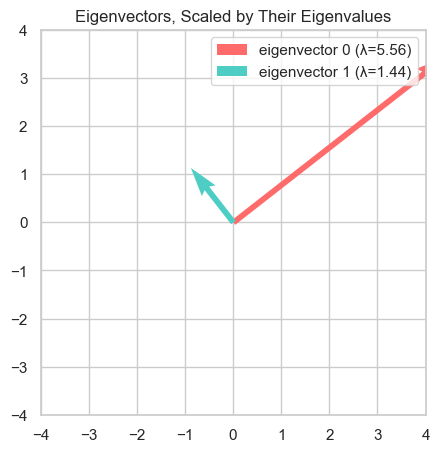

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))
origin = np.zeros(2)
colors = ["#ff6b6b", "#4ecdc4"]
for i in range(2):
    v = eigenvectors[:, i] * eigenvalues[i]
    ax.quiver(*origin, *v, angles="xy", scale_units="xy", scale=1, color=colors[i],
               label=f"eigenvector {i} (λ={eigenvalues[i]:.2f})", width=0.015)
ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.legend()
ax.set_title("Eigenvectors, Scaled by Their Eigenvalues")
ax.set_aspect("equal")
plt.show()


## 4. Probability — Common Distributions

Every classical ML algorithm implicitly assumes something about how data is distributed. Naive Bayes assumes (often) a Gaussian per feature per class; logistic regression's output is interpreted via the Bernoulli distribution. Visualizing these builds intuition for those assumptions.


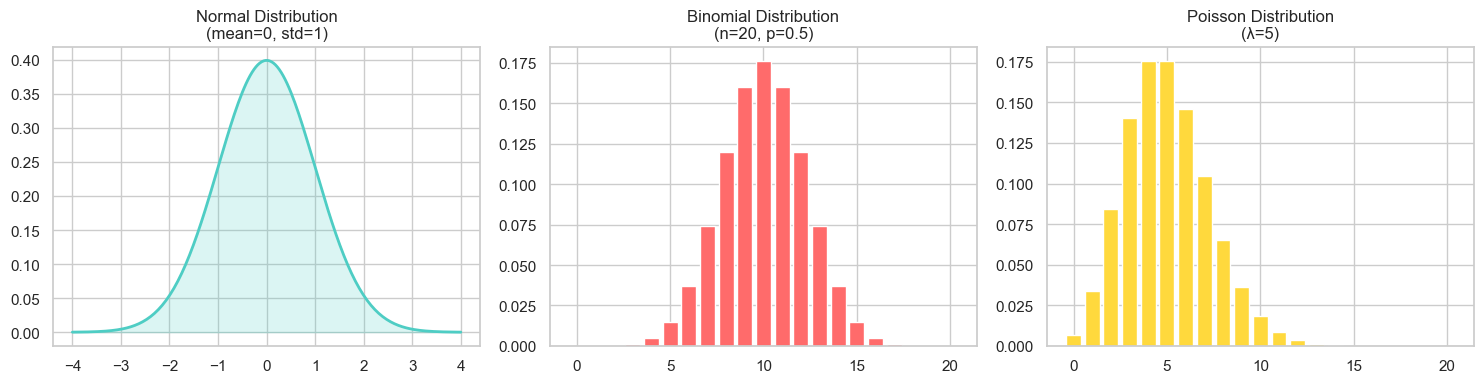

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Normal (Gaussian) — the most common assumption in classical ML
x_range = np.linspace(-4, 4, 200)
axes[0].plot(x_range, stats.norm.pdf(x_range, loc=0, scale=1), color="#4ecdc4", linewidth=2)
axes[0].set_title("Normal Distribution\n(mean=0, std=1)")
axes[0].fill_between(x_range, stats.norm.pdf(x_range), alpha=0.2, color="#4ecdc4")

# Binomial — discrete, e.g. "successes out of n trials" (relevant to classification accuracy)
k_range = np.arange(0, 21)
axes[1].bar(k_range, stats.binom.pmf(k_range, n=20, p=0.5), color="#ff6b6b")
axes[1].set_title("Binomial Distribution\n(n=20, p=0.5)")

# Poisson — discrete, e.g. "events per time window" (relevant to count-based features)
axes[2].bar(k_range, stats.poisson.pmf(k_range, mu=5), color="#ffd93d")
axes[2].set_title("Poisson Distribution\n(λ=5)")

plt.tight_layout()
plt.show()


## 5. Probability — Bayes' Theorem

Bayes' theorem is the entire foundation of the **Naive Bayes classifier**, covered later in Classical ML. We verify it numerically with a classic diagnostic-test example: a disease affects 1% of a population, and a test is 95% accurate — what's the real chance you have the disease given a positive test?


In [14]:
p_disease = 0.01                 # P(Disease) -- prior
p_pos_given_disease = 0.95       # P(Positive | Disease) -- test sensitivity
p_pos_given_healthy = 0.05       # P(Positive | Healthy) -- false positive rate


In [15]:
p_healthy = 1 - p_disease
p_positive = p_pos_given_disease * p_disease + p_pos_given_healthy * p_healthy   # law of total probability


In [16]:
# Bayes' theorem: P(Disease | Positive) = P(Positive | Disease) * P(Disease) / P(Positive)
p_disease_given_pos = (p_pos_given_disease * p_disease) / p_positive


In [17]:
print(f"P(Positive test)              = {p_positive:.4f}")
print(f"P(Disease | Positive test)    = {p_disease_given_pos:.4f}  ({p_disease_given_pos*100:.1f}%)")
print("\n-> Even with a 95%-accurate test, a positive result only means ~16% real risk,")
print("   because the disease is rare (a low PRIOR dominates the result). This exact")
print("   prior-times-likelihood mechanism is what Naive Bayes computes per class, per prediction.")


P(Positive test)              = 0.0590
P(Disease | Positive test)    = 0.1610  (16.1%)

-> Even with a 95%-accurate test, a positive result only means ~16% real risk,
   because the disease is rare (a low PRIOR dominates the result). This exact
   prior-times-likelihood mechanism is what Naive Bayes computes per class, per prediction.


## 6. Statistics — Covariance Matrix & The Central Limit Theorem

The covariance matrix generalizes topic 02's Pearson correlation to every feature pair at once — the same matrix PCA decomposes (see the eigenvector section above). We then demonstrate the **Central Limit Theorem (CLT)**: no matter how skewed the original data is, the distribution of *sample means* becomes approximately Normal as sample size grows — the theoretical justification for why so many statistical methods assume normality even when raw data doesn't look normal.


In [18]:
X = np.random.multivariate_normal(mean=[0, 0], cov=[[3, 1.5], [1.5, 2]], size=500)
cov_matrix = np.cov(X, rowvar=False)
print("Sample covariance matrix:\n", cov_matrix)


Sample covariance matrix:
 [[2.7743408  1.39693585]
 [1.39693585 1.94631702]]


In [19]:
# CLT demonstration: repeatedly sample means from a heavily skewed (exponential) population
population = np.random.exponential(scale=2, size=100_000)
sample_means = [np.mean(np.random.choice(population, size=40, replace=False)) for _ in range(2000)]


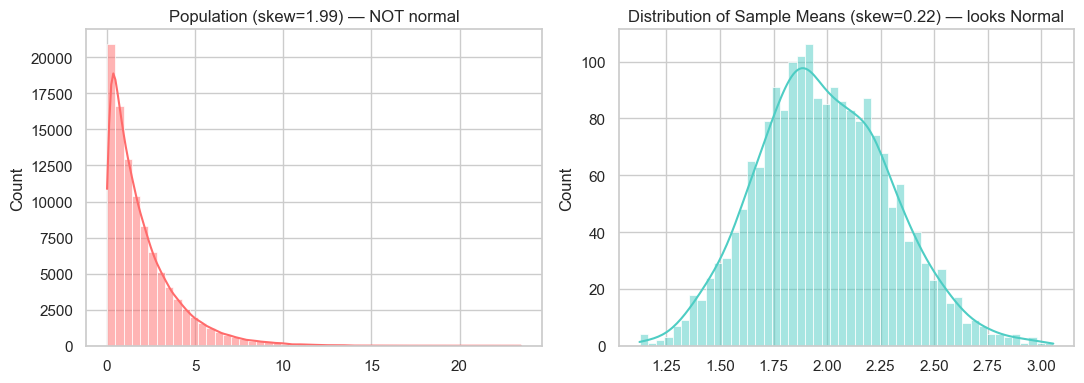

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(population, bins=50, ax=axes[0], color="#ff6b6b", kde=True)
axes[0].set_title(f"Population (skew={pd.Series(population).skew():.2f}) — NOT normal")
sns.histplot(sample_means, bins=50, ax=axes[1], color="#4ecdc4", kde=True)
axes[1].set_title(f"Distribution of Sample Means (skew={pd.Series(sample_means).skew():.2f}) — looks Normal")
plt.tight_layout()
plt.show()


## 7. Calculus — Derivatives, Gradients & Gradient Descent

**Gradient descent** is how almost every ML model (Logistic Regression, Neural Networks, Gradient Boosting) actually learns: repeatedly step in the direction that most reduces a loss function. We minimize a simple bowl-shaped function $f(x) = (x-3)^2 + 2$ by hand-rolled gradient descent, and watch it converge to the true minimum at $x=3$.


In [21]:
def f(x):
    return (x - 3) ** 2 + 2


In [22]:
def gradient(x):
    return 2 * (x - 3)   # derivative of f, computed analytically


In [23]:
x_current = -5.0          # start far from the minimum
learning_rate = 0.1
history = [x_current]


In [24]:
for step in range(30):
    grad = gradient(x_current)
    x_current = x_current - learning_rate * grad   # the gradient descent update rule
    history.append(x_current)
print(f"Started at x = {history[0]}, converged to x = {history[-1]:.4f} (true minimum is x = 3)")


Started at x = -5.0, converged to x = 2.9901 (true minimum is x = 3)


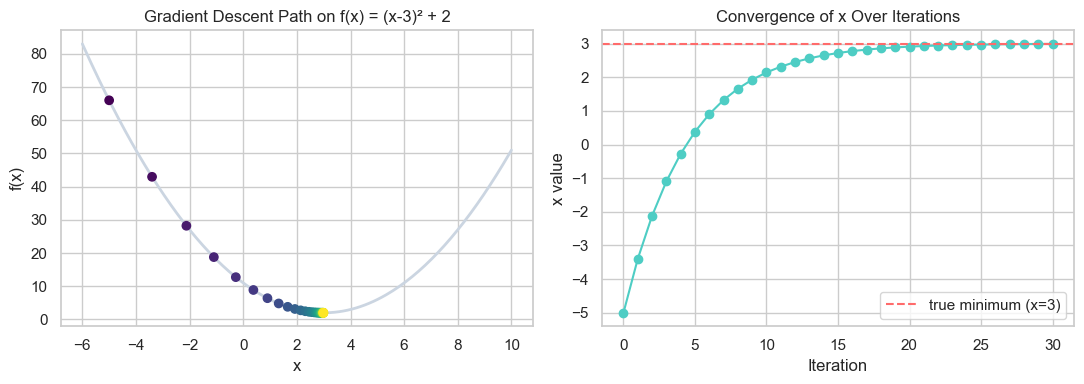

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x_plot = np.linspace(-6, 10, 200)
axes[0].plot(x_plot, f(x_plot), color="#cbd5e1", linewidth=2, zorder=1)
axes[0].scatter(history, [f(x) for x in history], c=range(len(history)), cmap="viridis", zorder=2)
axes[0].set_title("Gradient Descent Path on f(x) = (x-3)² + 2")
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")
axes[1].plot(history, marker="o", color="#4ecdc4")
axes[1].axhline(3, color="#ff6b6b", linestyle="--", label="true minimum (x=3)")
axes[1].set_title("Convergence of x Over Iterations")
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("x value")
axes[1].legend()
plt.tight_layout()
plt.show()


## 8. Matrix Rank & Singular Matrices

The **rank** of a matrix is the number of linearly independent rows/columns — informally, how much genuinely distinct information it contains. A matrix is **singular** (non-invertible) when its rank is less than its size, which happens when two features are perfectly collinear — the exact failure mode behind "perfect multicollinearity" in linear regression.


In [26]:
full_rank_matrix = np.array([[1, 2], [3, 5]], dtype=float)
singular_matrix = np.array([[1, 2], [2, 4]], dtype=float)   # row 2 = 2 * row 1 -> not independent


In [27]:
print("Full-rank matrix:\n", full_rank_matrix)
print("Rank:", np.linalg.matrix_rank(full_rank_matrix), "| Determinant:", np.linalg.det(full_rank_matrix).round(3))


Full-rank matrix:
 [[1. 2.]
 [3. 5.]]
Rank: 2 | Determinant: -1.0


In [28]:
print("\nSingular matrix:\n", singular_matrix)
print("Rank:", np.linalg.matrix_rank(singular_matrix), "| Determinant:", np.linalg.det(singular_matrix).round(3))
print("\n-> Determinant is (numerically) zero and rank < 2 -> this matrix cannot be inverted.")



Singular matrix:
 [[1. 2.]
 [2. 4.]]
Rank: 1 | Determinant: 0.0

-> Determinant is (numerically) zero and rank < 2 -> this matrix cannot be inverted.


## 9. Singular Value Decomposition (SVD)

SVD factors any matrix $A$ into $A = U\Sigma V^T$, where $\Sigma$ holds the **singular values** (non-negative, sorted largest-first) measuring how much each direction stretches space. SVD is the numerically stable machinery underneath PCA (Part I) — in fact, PCA's principal components are exactly the right singular vectors ($V$) of the (centered) data matrix.


In [29]:
A = np.array([[3, 1], [1, 3], [1, 1]], dtype=float)   # 3 samples, 2 features

U, S, Vt = np.linalg.svd(A, full_matrices=False)
print("Singular values:", S.round(3))
print("\nReconstructing A from U, S, V^T:")
A_reconstructed = U @ np.diag(S) @ Vt
print(A_reconstructed.round(3))
print("\nMatches original A?", np.allclose(A, A_reconstructed))


Singular values: [4.243 2.   ]

Reconstructing A from U, S, V^T:
[[3. 1.]
 [1. 3.]
 [1. 1.]]

Matches original A? True


## 10. Conditional Probability & Independence

$P(A \mid B) = P(A)$ exactly when $A$ and $B$ are **independent** — knowing $B$ tells you nothing new about $A$. We verify this numerically by simulating two dice: one fair roll (independent trials) and one rigged case (dependent).


In [30]:
np.random.seed(5)
n_trials = 100_000


In [31]:
# Independent case: two separate fair die rolls
die_a = np.random.randint(1, 7, n_trials)
die_b = np.random.randint(1, 7, n_trials)


In [32]:
p_a_is_6 = (die_a == 6).mean()
p_a_given_b = (die_a[die_b == 6] == 6).mean()   # P(die_a == 6 | die_b == 6), estimated from the subset where die_b == 6


In [33]:
print(f"P(die_a == 6)              = {p_a_is_6:.4f}")
print(f"P(die_a == 6 | die_b == 6) = {p_a_given_b:.4f}")
print("-> Nearly identical -> confirms the two dice are independent, as constructed.")


P(die_a == 6)              = 0.1666
P(die_a == 6 | die_b == 6) = 0.1624
-> Nearly identical -> confirms the two dice are independent, as constructed.


## 11. Confidence Intervals — Simulation

A 95% confidence interval is constructed so that, **if you repeated the sampling process many times**, about 95% of the intervals you'd build would contain the true population mean. We verify this definition directly by simulation rather than just quoting the formula.


In [34]:
true_mean = 50
population = np.random.normal(true_mean, 10, 100_000)


In [35]:
captured = 0
n_experiments = 200
for _ in range(n_experiments):
    sample = np.random.choice(population, size=40, replace=False)
    sample_mean = sample.mean()
    se = sample.std(ddof=1) / np.sqrt(len(sample))
    ci_lower, ci_upper = sample_mean - 1.96 * se, sample_mean + 1.96 * se
    if ci_lower <= true_mean <= ci_upper:
        captured += 1


In [36]:
print(f"True mean captured in {captured}/{n_experiments} = {captured/n_experiments:.1%} of 95% confidence intervals")
print("-> Should land close to 95%, confirming the CI's theoretical coverage guarantee empirically.")


True mean captured in 189/200 = 94.5% of 95% confidence intervals
-> Should land close to 95%, confirming the CI's theoretical coverage guarantee empirically.


## 12. Hypothesis Testing — the t-test

A **t-test** checks whether two samples' means differ by more than chance would explain. The **p-value** is the probability of seeing a difference this large (or larger) if the null hypothesis (no real difference) were true — a small p-value (conventionally < 0.05) is evidence against the null.


In [37]:
group_control = np.random.normal(50, 10, 100)
group_treatment = np.random.normal(55, 10, 100)   # a real +5 effect built into the simulation


In [38]:
t_stat, p_value = stats.ttest_ind(group_control, group_treatment)
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value:.5f}")
print(f"\n-> p < 0.05? {p_value < 0.05} -> {'reject' if p_value < 0.05 else 'fail to reject'} the null hypothesis of no difference.")
print("   This is the same statistical machinery behind comparing two models' performance in the")
print("   Model Evaluation & Tuning notebooks later in Classical ML.")


t-statistic: -2.239
p-value:     0.02626

-> p < 0.05? True -> reject the null hypothesis of no difference.
   This is the same statistical machinery behind comparing two models' performance in the
   Model Evaluation & Tuning notebooks later in Classical ML.


## 13. Partial Derivatives — Numerical Gradient via Finite Differences

For a multivariable function, the partial derivative $\frac{\partial f}{\partial x_i}$ measures the rate of change along just one axis, holding the others fixed. When an analytical derivative is inconvenient, a **finite-difference approximation** estimates it directly: $\frac{\partial f}{\partial x_i} \approx \frac{f(x + h\, e_i) - f(x - h\, e_i)}{2h}$ for a small step $h$.


In [39]:
def f_2d(x, y):
    return x**2 + 3 * y**2   # true gradient: (2x, 6y)


In [40]:
def numerical_gradient(f, x, y, h=1e-5):
    df_dx = (f(x + h, y) - f(x - h, y)) / (2 * h)
    df_dy = (f(x, y + h) - f(x, y - h)) / (2 * h)
    return df_dx, df_dy


In [41]:
point = (2.0, 1.0)
numerical = numerical_gradient(f_2d, *point)
analytical = (2 * point[0], 6 * point[1])


In [42]:
print(f"Numerical gradient at {point}:  ({numerical[0]:.5f}, {numerical[1]:.5f})")
print(f"Analytical gradient at {point}: {analytical}")
print("-> They match to 5 decimal places -> this is how frameworks like PyTorch verify custom gradients (gradcheck).")


Numerical gradient at (2.0, 1.0):  (4.00000, 6.00000)
Analytical gradient at (2.0, 1.0): (4.0, 6.0)
-> They match to 5 decimal places -> this is how frameworks like PyTorch verify custom gradients (gradcheck).


## 14. Multivariate Gradient Descent — 2D Contour Visualization

Scaling gradient descent from the 1D toy example (Part IV, section 2) to two dimensions changes nothing about the update rule — just the dimensionality of $\nabla f$. Visualizing the descent path on a contour plot makes the "always downhill" behavior directly visible.


In [43]:
def f_bowl(x, y):
    return (x - 2) ** 2 + 3 * (y + 1) ** 2


In [44]:
def grad_bowl(x, y):
    return np.array([2 * (x - 2), 6 * (y + 1)])


In [45]:
pos = np.array([-4.0, 3.0])
lr = 0.1
path_2d = [pos.copy()]
for _ in range(40):
    pos = pos - lr * grad_bowl(*pos)
    path_2d.append(pos.copy())
path_2d = np.array(path_2d)


In [46]:
x_grid, y_grid = np.meshgrid(np.linspace(-5, 4, 100), np.linspace(-4, 4, 100))
z_grid = f_bowl(x_grid, y_grid)


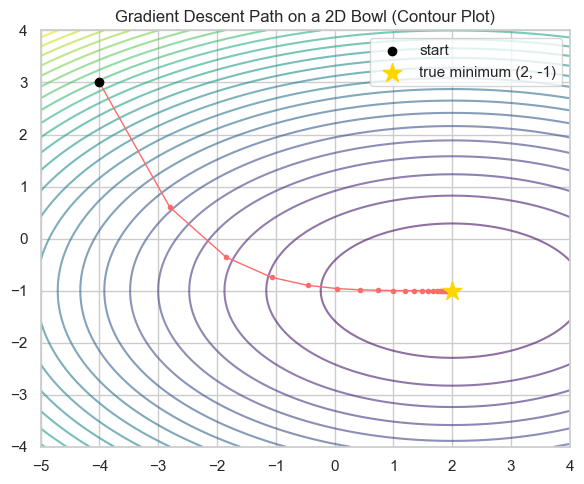

Converged to: (1.9992, -1.0000), true minimum: (2, -1)


In [47]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.contour(x_grid, y_grid, z_grid, levels=25, cmap="viridis", alpha=0.6)
ax.plot(path_2d[:, 0], path_2d[:, 1], "o-", color="#ff6b6b", markersize=3, linewidth=1)
ax.scatter(*path_2d[0], color="black", zorder=5, label="start")
ax.scatter(2, -1, color="gold", marker="*", s=200, zorder=5, label="true minimum (2, -1)")
ax.set_title("Gradient Descent Path on a 2D Bowl (Contour Plot)")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Converged to: ({path_2d[-1][0]:.4f}, {path_2d[-1][1]:.4f}), true minimum: (2, -1)")


## 15. Law of Large Numbers — Why More Data Helps

The **Law of Large Numbers (LLN)** states that as sample size $n$ grows, the sample mean $\bar{X}$ converges to the true population mean $\mu$. This is the formal justification for "more training data generally helps": estimates computed from data (feature means, class probabilities, model parameters) get more reliable as $n$ increases.


In [48]:
true_mean = 7.0
population = np.random.exponential(scale=true_mean, size=1_000_000)


In [49]:
sample_sizes = [5, 20, 100, 1000, 10000, 100000]
running_means = [population[:n].mean() for n in sample_sizes]


In [50]:
for n, m in zip(sample_sizes, running_means):
    print(f"n = {n:>7,} -> sample mean = {m:.3f} (true mean = {true_mean})")


n =       5 -> sample mean = 15.615 (true mean = 7.0)
n =      20 -> sample mean = 11.719 (true mean = 7.0)
n =     100 -> sample mean = 8.128 (true mean = 7.0)
n =   1,000 -> sample mean = 6.834 (true mean = 7.0)
n =  10,000 -> sample mean = 6.984 (true mean = 7.0)
n = 100,000 -> sample mean = 6.995 (true mean = 7.0)


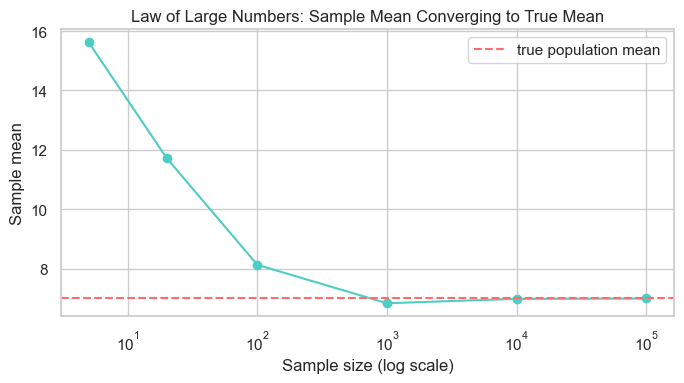

In [51]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sample_sizes, running_means, marker="o", color="#4ecdc4")
ax.axhline(true_mean, color="#ff6b6b", linestyle="--", label="true population mean")
ax.set_xscale("log")
ax.set_xlabel("Sample size (log scale)")
ax.set_ylabel("Sample mean")
ax.set_title("Law of Large Numbers: Sample Mean Converging to True Mean")
ax.legend()
plt.tight_layout()
plt.show()


## ✅ Key Takeaways

- **Linear algebra** (vectors, matrix inversion, eigenvectors) is the data structure and the solver behind Linear Regression's normal equation and PCA's variance-maximizing directions.
- **Probability** (distributions, Bayes' theorem) is the direct foundation of Naive Bayes, and the reasoning tool behind every "how confident is this prediction" question.
- **The Central Limit Theorem** is why so many statistical procedures (confidence intervals, hypothesis tests) can assume normality even on real-world, non-normal data — as long as they operate on sample means with a reasonably large sample size.
- **Gradient descent**, demonstrated here on both a 1D toy function and a 2D contour-visualized bowl, is *exactly* the same update rule (scaled up to many parameters) that trains Logistic Regression, Neural Networks, and Gradient Boosting models later in this series.
- **SVD** is the numerically stable machinery underneath PCA — its singular vectors *are* PCA's principal components, just computed a more robust way.
- **Confidence intervals and hypothesis tests (t-tests)** are how you'll rigorously compare two models' performance later, instead of eyeballing which accuracy number looks bigger.
- Numerical (finite-difference) gradients matching analytical ones is literally how frameworks like PyTorch's `gradcheck` verify custom-written gradients are correct.
- Every one of these concepts will be explicitly referenced again by name in the Classical ML notebooks — this topic is the payoff for reading the math sections carefully.

**Foundation complete.** Next: the [Classical ML repository](https://github.com/mdnuruzzamanKALLOL/Statistical-Machine-Learning-Classical-ML) — starting with Regression, where the normal equation from section 2 makes its first real appearance.
